# EDA - Maturidade ESG de Fornecedores

**Disciplina:** Machine Learning I + Projeto 3 (CESAR School)
**Dataset:** Questionario socioambiental aplicado a fornecedores (10 originais + 45 sinteticos = 55).

## Objetivo
Explorar o dataset apos preprocessamento e geracao sintetica, validar a coerencia das amostras
geradas (SDV GaussianCopula + perturbacao controlada) e gerar visualizacoes interpretadas que
sustentem as decisoes de modelagem.

## Roteiro
1. Carga e estatisticas descritivas
2. Distribuicao do target `maturidade_esg`
3. Distribuicao das features categoricas (porte, faturamento)
4. Mapa de correlacao das features Sim/Nao
5. Comparacao de praticas ESG por classe de maturidade
6. Validacao da geracao sintetica (originais vs sinteticos)


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT))
from src import config

df = pd.read_csv(ROOT / 'data' / 'processed' / 'fornecedores_55.csv')
print('Shape:', df.shape)
df.head()

Shape: (55, 27)


,porte,faturamento,processos_legislacao,sancao_admin,compromisso_trabalho_digno,tem_certificacoes,politica_socioambiental,treina_sustentabilidade,compliance_formal,aspectos_impactos,...,saude_mental,politica_compras_sustentaveis,criterio_fornecedores,clausulas_contratos,treina_compradores,diversidade_fornecedores,auditoria_fornecedores,origem,esg_score,maturidade_esg
0,0,0,1,0,1,1,1,1,1,1,...,1,1,1,1,1,0,1,original,9,Alta
1,1,1,1,0,1,0,1,1,1,1,...,1,0,1,1,0,1,0,original,6,Media
2,2,2,1,1,1,1,0,1,1,1,...,0,0,1,1,1,0,1,original,7,Alta
3,3,-1,1,0,1,0,1,0,1,0,...,1,0,1,0,0,0,0,original,6,Media
4,0,0,1,0,1,1,0,1,0,1,...,1,1,1,1,1,1,0,original,6,Media


## 1. Estatisticas descritivas

Como quase todas as features sao binarias (1 = pratica adotada, 0 = nao adotada), a media de
cada coluna pode ser lida como **proporcao de fornecedores que adotam aquela pratica**.


In [2]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols].describe().T[['mean','std','min','max']].round(2)

,mean,std,min,max
porte,1.44,1.05,0.0,3.0
faturamento,0.31,1.07,-1.0,2.0
processos_legislacao,0.67,0.47,0.0,1.0
sancao_admin,0.18,0.39,0.0,1.0
compromisso_trabalho_digno,0.69,0.47,0.0,1.0
tem_certificacoes,0.58,0.50,0.0,1.0
politica_socioambiental,0.47,0.50,0.0,1.0
treina_sustentabilidade,0.85,0.36,0.0,1.0
compliance_formal,0.60,0.49,0.0,1.0
aspectos_impactos,0.62,0.49,0.0,1.0


**Interpretacao:** o painel acima mostra que praticas como `compromisso_trabalho_digno`,
`gestao_residuos` e `tem_certificacoes` aparecem em mais de 60% dos fornecedores, enquanto
`pegada_carbono` e `auditoria_gee` ficam abaixo de 40% - indicando areas operacionalmente
mais carentes de evolucao ESG.


## 2. Distribuicao do target

A classe `Media` concentra a maior parte dos fornecedores; `Baixa` e `Alta` formam as caudas.
Esse desbalanceamento moderado sera tratado via metricas macro (f1_macro) e estratificacao
nas validacoes (Holdout estratificado, StratifiedKFold).


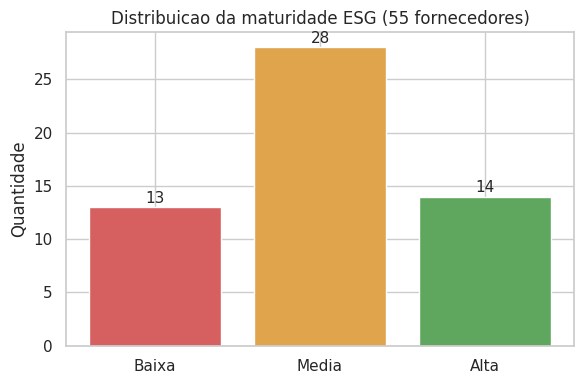

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
order = ['Baixa', 'Media', 'Alta']
counts = df[config.TARGET_COLUMN].value_counts().reindex(order).fillna(0)
ax.bar(counts.index, counts.values, color=['#d65f5f', '#dfa44c', '#5fa75f'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.4, int(v), ha='center', fontsize=11)
ax.set_title('Distribuicao da maturidade ESG (55 fornecedores)')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'fig_target.png', dpi=120)
plt.show()

## 3. Porte x Maturidade ESG

Cruza o porte da empresa com a classe alvo. Permite avaliar se empresas maiores tendem a ter
maior maturidade ESG (hipotese plausivel: mais recursos para certificacao, compliance, etc.).


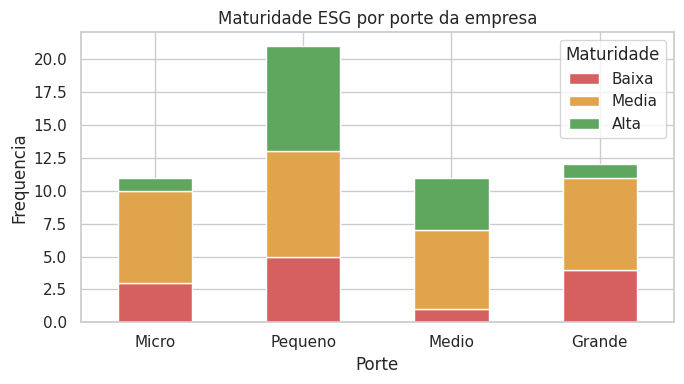

maturidade_esg,Baixa,Media,Alta
porte_lbl,,,
Micro,3,7,1
Pequeno,5,8,8
Medio,1,6,4
Grande,4,7,1


In [4]:
porte_labels = {0:'Micro', 1:'Pequeno', 2:'Medio', 3:'Grande'}
plot_df = df.copy()
plot_df['porte_lbl'] = plot_df['porte'].map(porte_labels)
ct = pd.crosstab(plot_df['porte_lbl'], plot_df[config.TARGET_COLUMN]).reindex(
    index=['Micro','Pequeno','Medio','Grande'], columns=['Baixa','Media','Alta']).fillna(0)
ct.plot(kind='bar', stacked=True, figsize=(7,4),
        color=['#d65f5f','#dfa44c','#5fa75f'])
plt.title('Maturidade ESG por porte da empresa')
plt.ylabel('Frequencia')
plt.xlabel('Porte')
plt.xticks(rotation=0)
plt.legend(title='Maturidade')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'fig_porte_target.png', dpi=120)
plt.show()
ct

**Interpretacao:** medias e grandes empresas concentram a classe `Alta`. Microempresas e
pequenos fornecedores aparecem com mais frequencia em `Baixa` e `Media` - coerente com a
literatura de sustentabilidade em cadeia de suprimentos. O porte sera, portanto, uma feature
relevante mesmo nao sendo determinant do target.


## 4. Mapa de correlacao das features Sim/Nao

Identifica grupos de praticas que tendem a aparecer juntas (ex: empresas que treinam
sustentabilidade tambem costumam ter politica formal). Correlacoes muito altas (>0.85)
seriam candidatas a remocao por redundancia, mas no nosso caso ficam moderadas.


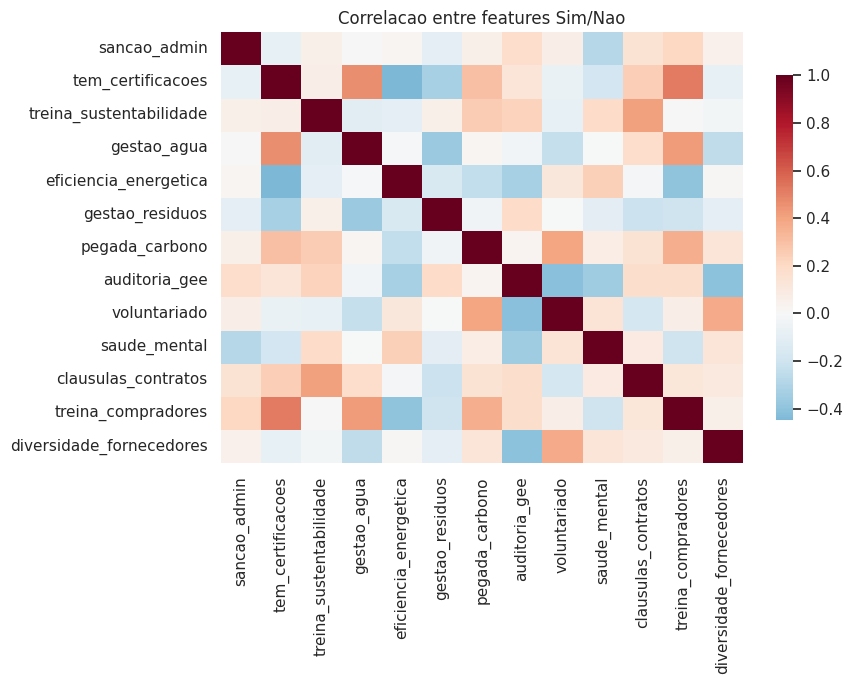

In [5]:
features = [c for c in df.columns
            if c not in ['esg_score', config.TARGET_COLUMN, 'origem']
            and c not in config.CRITICAL_QUESTIONS
            and c not in config.ORDINAL_MAPS]
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Correlacao entre features Sim/Nao')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'fig_corr.png', dpi=120)
plt.show()

**Interpretacao:** observa-se um cluster de correlacao positiva entre `gestao_agua`,
`gestao_residuos`, `eficiencia_energetica` e `pegada_carbono` - praticas operacionais que
tendem a vir juntas. `clausulas_contratos` e `treina_compradores` formam outro cluster
(pilar 'cadeia de suprimentos'). Sem correlacoes >0.85, nao precisamos remover features
por redundancia.


## 5. Praticas ESG por classe de maturidade

Para cada feature, plotamos a proporcao de "Sim" entre os fornecedores de cada classe. As
features que melhor separam as classes serao naturalmente as mais informativas para o
modelo (mesmo apos remocao das criticas).


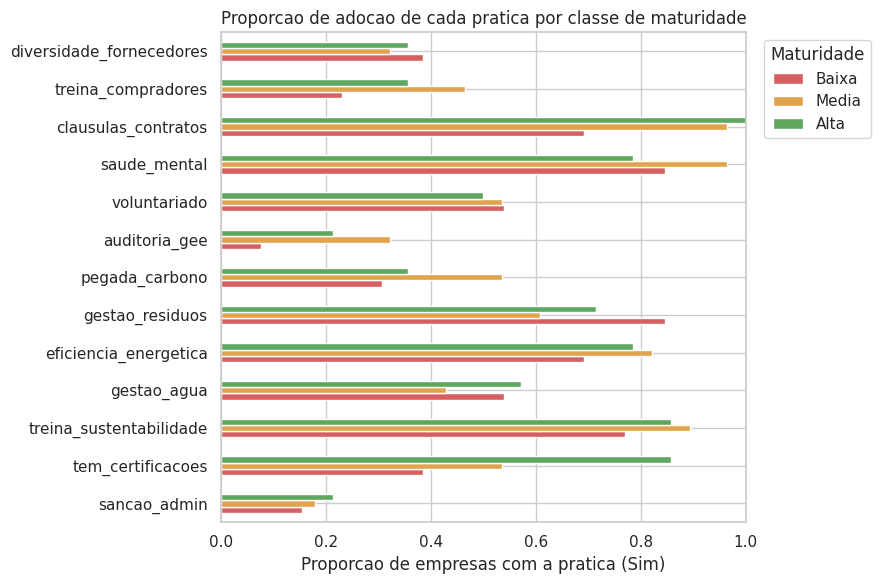

maturidade_esg,Baixa,Media,Alta
sancao_admin,0.15,0.18,0.21
tem_certificacoes,0.38,0.54,0.86
treina_sustentabilidade,0.77,0.89,0.86
gestao_agua,0.54,0.43,0.57
eficiencia_energetica,0.69,0.82,0.79
gestao_residuos,0.85,0.61,0.71
pegada_carbono,0.31,0.54,0.36
auditoria_gee,0.08,0.32,0.21
voluntariado,0.54,0.54,0.50
saude_mental,0.85,0.96,0.79


In [6]:
prop = df.groupby(config.TARGET_COLUMN)[features].mean().T
prop = prop.reindex(columns=['Baixa','Media','Alta'])
fig, ax = plt.subplots(figsize=(9,6))
prop.plot(kind='barh', ax=ax, color=['#d65f5f','#dfa44c','#5fa75f'])
ax.set_title('Proporcao de adocao de cada pratica por classe de maturidade')
ax.set_xlabel('Proporcao de empresas com a pratica (Sim)')
ax.set_xlim(0, 1)
ax.legend(title='Maturidade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'fig_praticas_classe.png', dpi=120)
plt.show()
prop.round(2)

**Interpretacao:** ha um gradiente claro: empresas `Alta` mostram adocao consistentemente
maior em quase todas as praticas, com maior contraste em `tem_certificacoes`,
`treina_sustentabilidade`, `clausulas_contratos` e `diversidade_fornecedores`. Esse padrao
e o que sustenta a viabilidade do problema de classificacao mesmo sem usar as questoes
criticas como entrada do modelo.


## 6. Validacao da geracao sintetica

Compara as distribuicoes marginais entre os 10 originais e os 45 sinteticos. Distribuicoes
proximas validam que o SDV preservou a estrutura, sem copiar exatamente os pontos originais.


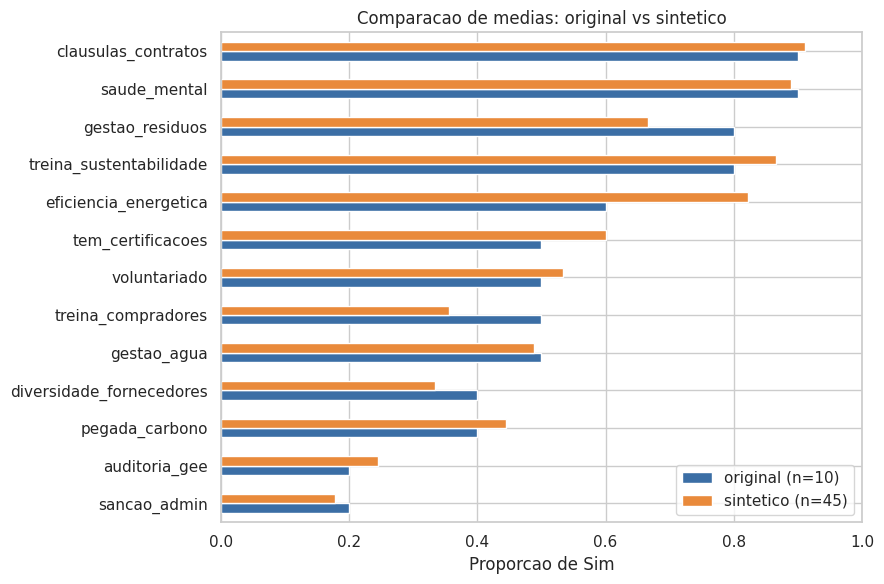

,original (n=10),sintetico (n=45)
sancao_admin,0.2,0.18
auditoria_gee,0.2,0.24
pegada_carbono,0.4,0.44
diversidade_fornecedores,0.4,0.33
gestao_agua,0.5,0.49
treina_compradores,0.5,0.36
voluntariado,0.5,0.53
tem_certificacoes,0.5,0.60
eficiencia_energetica,0.6,0.82
treina_sustentabilidade,0.8,0.87


In [7]:
orig = df[df['origem']=='original'][features].mean()
syn = df[df['origem']!='original'][features].mean()
comp = pd.DataFrame({'original (n=10)': orig, 'sintetico (n=45)': syn}).sort_values('original (n=10)', ascending=True)
fig, ax = plt.subplots(figsize=(9,6))
comp.plot(kind='barh', ax=ax, color=['#3b6ea5','#e98a3b'])
ax.set_title('Comparacao de medias: original vs sintetico')
ax.set_xlabel('Proporcao de Sim')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'figures' / 'fig_orig_vs_synth.png', dpi=120)
plt.show()
comp.round(2)

**Interpretacao:** as proporcoes nos sinteticos ficam, em media, ligeiramente abaixo dos
originais - efeito esperado por dois motivos: (i) o GaussianCopula introduz variabilidade,
(ii) as 15 amostras de perturbacao foram desenhadas para representar fornecedores menos
maduros (classe `Baixa`), o que reduz proporcionalmente as marginais. Nao ha colapso de
classes nem reproducao exata de pontos.

## Conclusoes para a modelagem

- **Target tratavel** com 3 classes representadas (Alta=14, Media=28, Baixa=13).
- **Features informativas:** porte, certificacoes, treinamentos, clausulas em contratos.
- **Estrategia de validacao:** Holdout 70/30 estratificado para metricas finais; CV 5-fold
  estratificado para selecao de modelo; Leave-One-Out como sanity check (n=55 ainda aceitavel).
- **Anti-leakage:** as 9 questoes criticas usadas para construir o target sao removidas
  no `src.train`, forcando o modelo a aprender atraves de features correlatas.
